# 🧪 시나리오 3: API 호출 제한 — 요청 수 vs 토큰 기반

## 이 실습에서 배우는 것

APIM에서 LLM API 호출을 제한하는 **두 가지 방식**을 직접 비교합니다.

| 방식 | 정책 | 제한 단위 | 특징 |
|---|---|---|---|
| **요청 수 기반** | `rate-limit` | 분당 N회 요청 | 모든 SKU에서 사용 가능, 단순함 |
| **토큰 기반** | `azure-openai-token-limit` | 분당 N 토큰 (TPM) | 실제 토큰 소비량 기준, Developer+ SKU |

### 왜 두 가지가 필요한가?

- **요청 수 기반**: "1분에 10번만 호출 가능" → 단순하지만, 요청마다 토큰량이 다르면 정밀하지 않음
- **토큰 기반**: "1분에 2,000 토큰까지" → LLM 비용에 직결되는 토큰 단위로 정밀 제어

### APIM Product란?

**Product = 여러 API를 묶어서 하나의 "서비스 패키지"로 제공하는 단위**입니다.

| 개념 | 역할 | 비유 |
|---|---|---|
| **API** | 개별 서비스 (OpenAI, Gemini 등) | 음성통화, 문자, 데이터 |
| **Product** | API를 묶은 패키지 + 정책 | 요금제 (기본, 프리미엄) |
| **Subscription** | 팀/앱이 Product에 가입 | 고객의 요금제 계약 |
| **Subscription Key** | 가입 후 받는 인증 키 | 유심 카드 |

### 실습 구성

이 실습에서는 **2개의 Product**를 만들어 각각 다른 제한 방식을 적용합니다.

```
┌─ Product A: Request Limited ────────────────────────┐
│  정책: rate-limit (분당 5회 요청)                      │
│  검증: 요청 횟수 초과 시 429                           │
└──────────────────────────────────────────────────────┘

┌─ Product B: Token Limited ──────────────────────────┐
│  정책: azure-openai-token-limit (분당 2,000 토큰)     │
│  검증: 토큰 소비 초과 시 429                           │
└──────────────────────────────────────────────────────┘
```

### 진행 순서

1. **Product/Subscription 자동 생성**
2. **실습 A: 요청 수 기반 제한 테스트** (`rate-limit`)
3. **실습 B: AI Gateway 토큰 기반 제한 테스트** (`azure-openai-token-limit`)
4. **비교 정리 + LLM 범용 토큰 제어 설명** (`llm-token-limit`)

> ⚠️ 이 실습은 **Developer SKU 이상**에서 실행해야 합니다.
> Consumption SKU에서는 `azure-openai-token-limit` 정책을 사용할 수 없습니다.

In [1]:
import os, time, json, subprocess
import requests
from dotenv import load_dotenv

load_dotenv("../../.env", override=True)

APIM_URL = os.getenv("APIM_URL")
APIM_NAME = os.getenv("APIM_NAME")
RESOURCE_GROUP = os.getenv("RESOURCE_GROUP")
DEPLOYMENT_NAME = os.getenv("DEPLOYMENT_NAME", "gpt-4.1-nano")
API_VERSION = "2025-04-01-preview"

assert APIM_URL, "❌ APIM_URL이 설정되지 않았습니다."
assert APIM_NAME, "❌ APIM_NAME이 설정되지 않았습니다."
assert RESOURCE_GROUP, "❌ RESOURCE_GROUP이 설정되지 않았습니다."

# SKU 확인
sku_result = subprocess.run(
    ["az", "apim", "show", "--name", APIM_NAME, "--resource-group", RESOURCE_GROUP, "--query", "sku.name", "-o", "tsv"],
    capture_output=True, text=True
)
SKU = sku_result.stdout.strip()

BASE_URL = f"{APIM_URL}/openai/deployments/{DEPLOYMENT_NAME}/chat/completions"

print("✅ 환경 설정 완료")
print(f"   APIM Name:   {APIM_NAME}")
print(f"   APIM URL:    {APIM_URL}")
print(f"   SKU:         {SKU}")
print(f"   Deployment:  {DEPLOYMENT_NAME}")

if SKU == "Consumption":
    print("\n⚠️ Consumption SKU입니다. 실습 B(토큰 기반)는 실행할 수 없습니다.")
    print("   Developer 이상 SKU로 재배포하세요.")

✅ 환경 설정 완료
   APIM Name:   apim-ai-gw-aigateway-20260317
   APIM URL:    https://apim-ai-gw-aigateway-20260317.azure-api.net
   SKU:         Developer
   Deployment:  gpt-4.1-nano


---
## 1단계: Product 생성 + API 추가 + Subscription 생성

아래 셀을 실행하면 **2개 Product**를 자동 생성하고,
각 Product에 Azure OpenAI API를 추가한 뒤, Subscription을 생성합니다.

| Product | 용도 | 적용할 정책 |
|---|---|---|
| Request Limited | 요청 수 기반 제한 실습 | `rate-limit` (5회/분) |
| Token Limited | 토큰 기반 제한 실습 | `azure-openai-token-limit` (2,000 TPM) |

아래 코드가 잘 적용되면 설정된 화면은 다음과 같습니다.

### Products
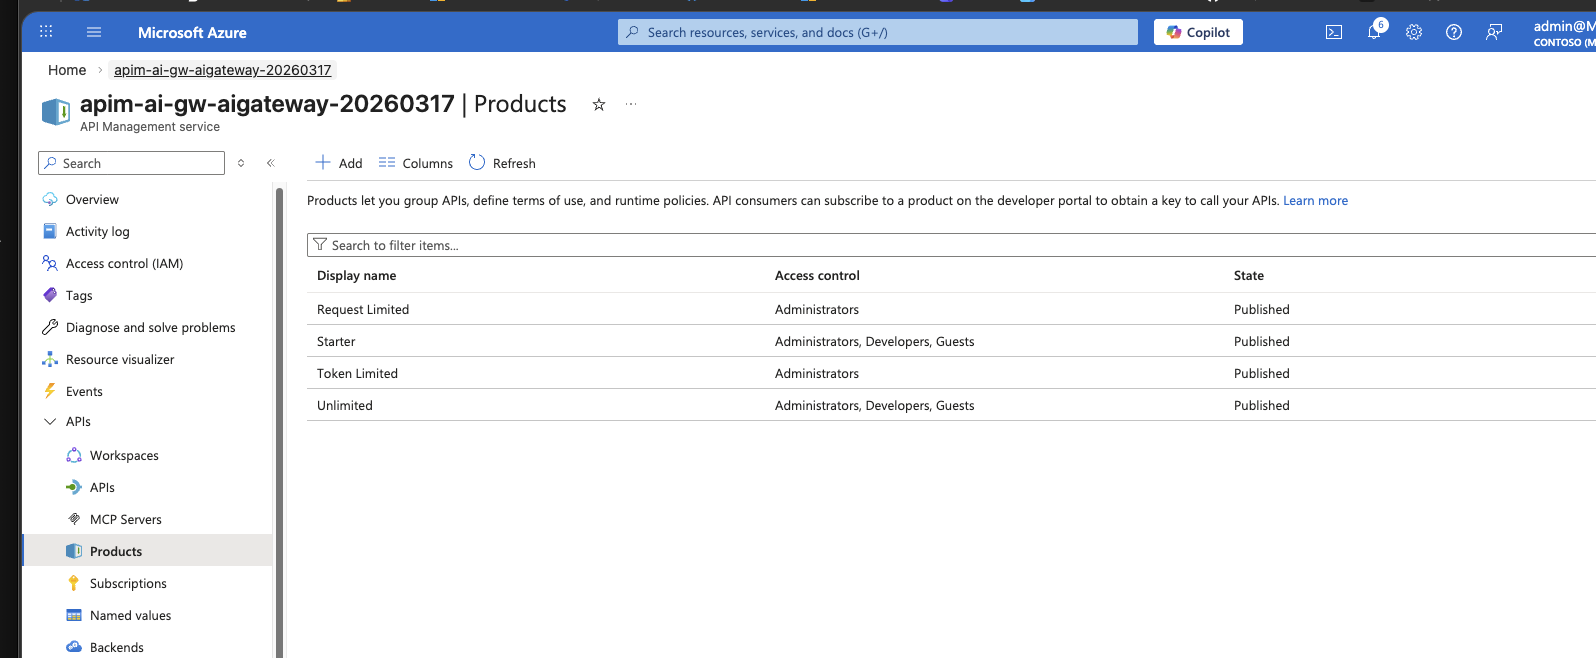

### Subscriptions
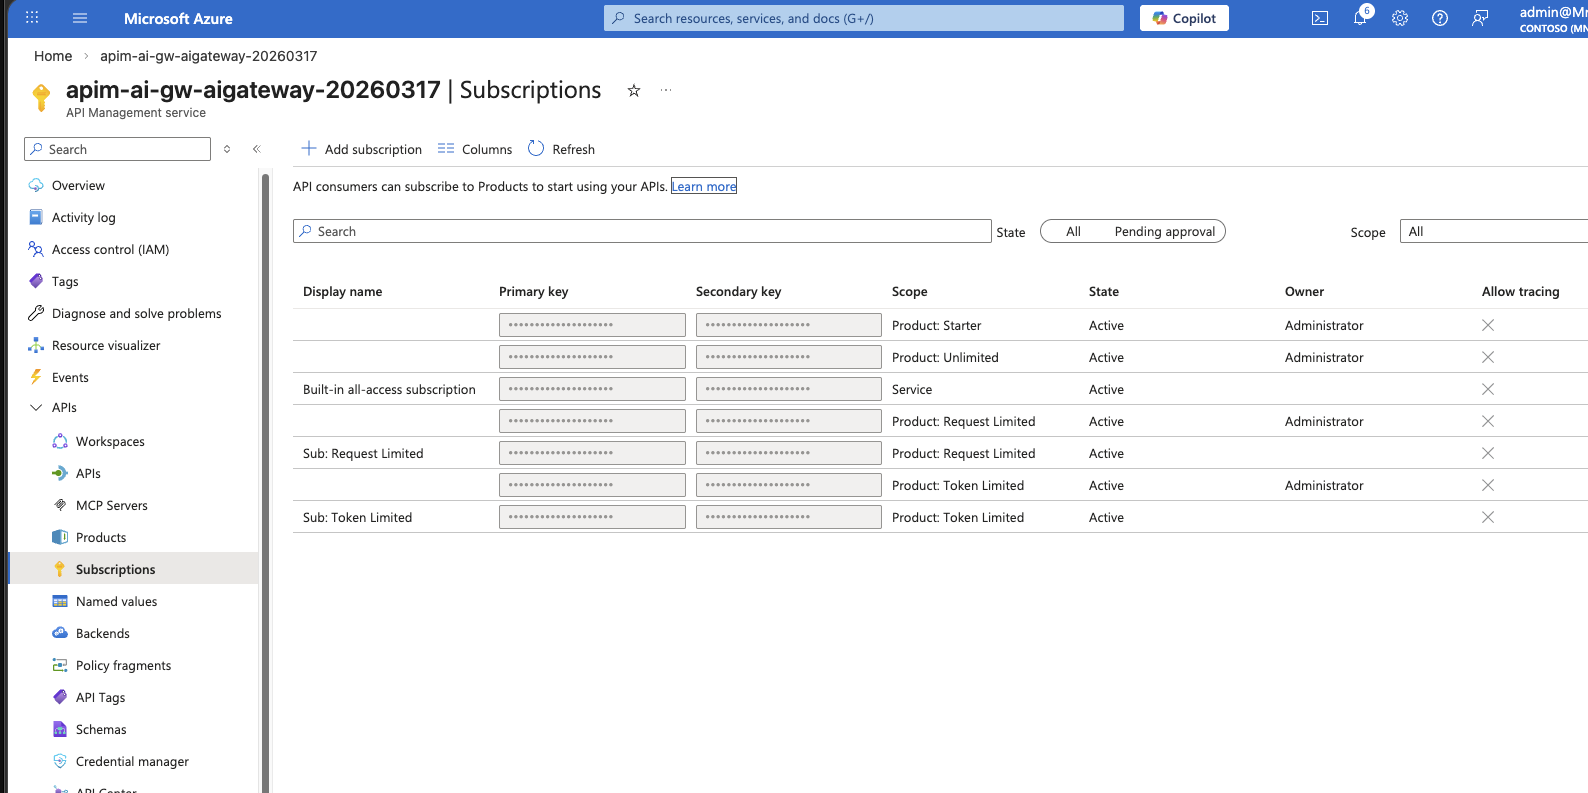

In [ ]:
PRODUCTS = [
    {"id": "request-limited",  "name": "Request Limited",  "desc": "요청 수 기반 제한 실습용",  "env_key": "APIM_KEY_REQUEST_LIMITED",  "sub_id": "sub-request-limited",  "sub_name": "Sub: Request Limited"},
    {"id": "token-limited",    "name": "Token Limited",    "desc": "토큰 기반 제한 실습용",    "env_key": "APIM_KEY_TOKEN_LIMITED",    "sub_id": "sub-token-limited",    "sub_name": "Sub: Token Limited"},
]

# APIM ID 조회
apim_id_result = subprocess.run(
    ["az", "apim", "show", "--name", APIM_NAME, "--resource-group", RESOURCE_GROUP, "--query", "id", "-o", "tsv"],
    capture_output=True, text=True
)
APIM_ID = apim_id_result.stdout.strip()
assert APIM_ID, "❌ APIM ID 조회 실패"

# Azure OpenAI API ID 찾기
api_id_result = subprocess.run(
    ["az", "apim", "api", "list", "--resource-group", RESOURCE_GROUP, "--service-name", APIM_NAME,
     "--query", "[?contains(name,'openai') || contains(properties.displayName,'OpenAI')].name", "-o", "tsv"],
    capture_output=True, text=True
)
API_ID = api_id_result.stdout.strip().split("\n")[0] if api_id_result.stdout.strip() else "azure-openai"
print(f"📌 APIM ID: ...{APIM_ID[-30:]}")
print(f"📌 Azure OpenAI API ID: {API_ID}\n")

for p in PRODUCTS:
    print(f"{'─'*50}")
    print(f"▶ {p['name']}")

    # 1. Product 생성
    product_url = f"https://management.azure.com{APIM_ID}/products/{p['id']}?api-version=2023-09-01-preview"
    product_body = json.dumps({
        "properties": {
            "displayName": p["name"],
            "description": p["desc"],
            "subscriptionRequired": True,
            "approvalRequired": False,
            "state": "published"
        }
    })
    result = subprocess.run(
        ["az", "rest", "--method", "PUT", "--url", product_url, "--body", product_body],
        capture_output=True, text=True
    )
    print(f"  {'✅' if result.returncode == 0 else '❌'} Product 생성 {'완료' if result.returncode == 0 else '실패'}")

    # 2. Product에 API 추가
    api_link_url = f"https://management.azure.com{APIM_ID}/products/{p['id']}/apis/{API_ID}?api-version=2023-09-01-preview"
    result = subprocess.run(
        ["az", "rest", "--method", "PUT", "--url", api_link_url, "--body", "{}"],
        capture_output=True, text=True
    )
    print(f"  {'✅' if result.returncode == 0 else '❌'} API 추가 {'완료' if result.returncode == 0 else '실패'}")

    # 3. Subscription 생성
    sub_url = f"https://management.azure.com{APIM_ID}/subscriptions/{p['sub_id']}?api-version=2023-09-01-preview"
    sub_body = json.dumps({
        "properties": {
            "displayName": p["sub_name"],
            "scope": f"{APIM_ID}/products/{p['id']}",
            "state": "active"
        }
    })
    result = subprocess.run(
        ["az", "rest", "--method", "PUT", "--url", sub_url, "--body", sub_body],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        sub_data = json.loads(result.stdout)
        key = sub_data.get("properties", {}).get("primaryKey", "")
        if not key:
            key_url = f"https://management.azure.com{APIM_ID}/subscriptions/{p['sub_id']}/listSecrets?api-version=2023-09-01-preview"
            key_result = subprocess.run(["az", "rest", "--method", "POST", "--url", key_url], capture_output=True, text=True)
            if key_result.returncode == 0:
                key = json.loads(key_result.stdout).get("primaryKey", "")
        print(f"  ✅ Subscription 생성 완료 — Key: {key[:8]}...{key[-4:]}" if key else "  ⚠️ Subscription 생성됨, 키 조회 실패")
        p["key"] = key
    else:
        print(f"  ❌ Subscription 생성 실패")
        p["key"] = ""

print(f"\n{'─'*50}")
print("\n📋 .env에 아래 값을 입력하세요:\n")
for p in PRODUCTS:
    if p.get("key"):
        print(f'  {p["env_key"]}="{p["key"]}"')
    else:
        print(f'  {p["env_key"]}="<Portal에서 확인>"')

---
## 2단계: 각 Product에 정책 적용

- **Product A (Request Limited)**: `rate-limit` — 분당 5회 요청 제한
- **Product B (Token Limited)**: `azure-openai-token-limit` — 분당 2,000 토큰 제한

아래 코드가 잘 적용되면 **APIM -> Products에서 각 Product 별 Poilcy를 볼 수 있습니다.
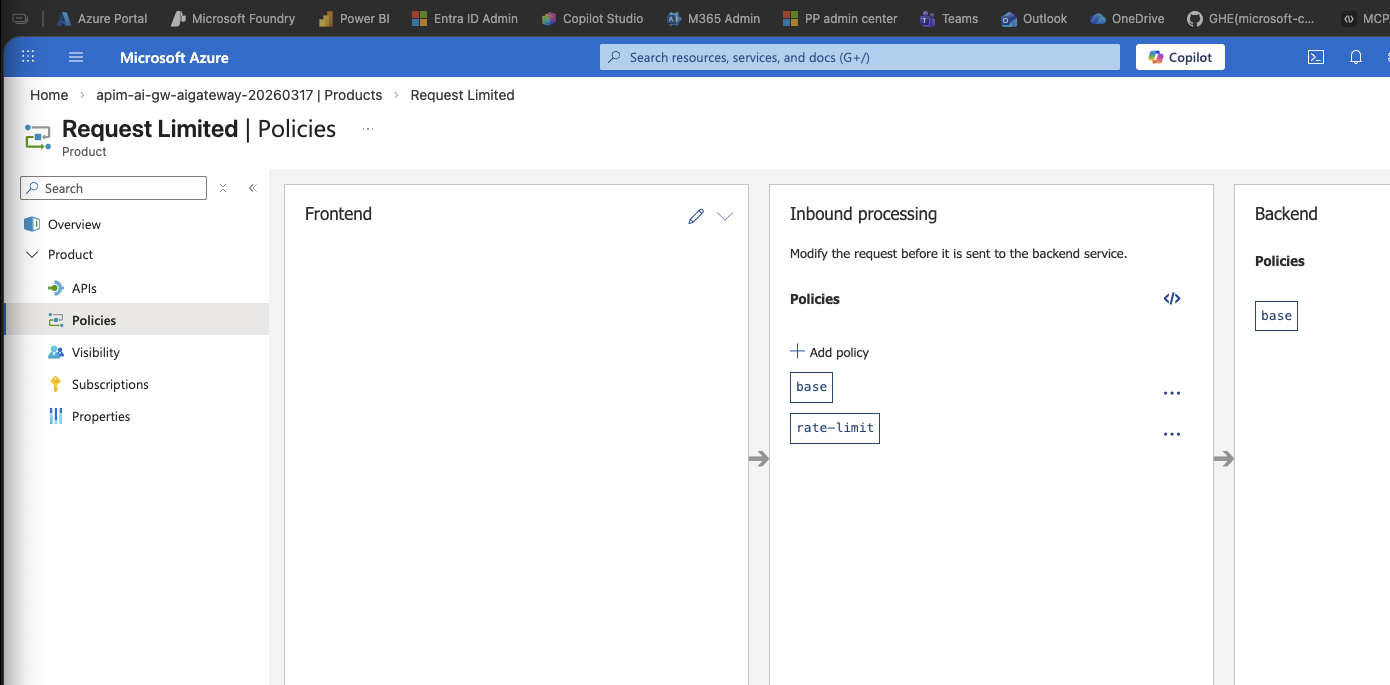

In [3]:
# ── Product A: 요청 수 기반 (rate-limit) ──
rate_limit_xml = """<policies>
    <inbound>
        <base />
        <rate-limit calls="5" renewal-period="60"
            remaining-calls-header-name="x-ratelimit-remaining-calls"
            retry-after-header-name="Retry-After" />
    </inbound>
    <backend><base /></backend>
    <outbound><base /></outbound>
    <on-error><base /></on-error>
</policies>"""

# ── Product B: 토큰 기반 (azure-openai-token-limit) ──
token_limit_xml = """<policies>
    <inbound>
        <base />
        <azure-openai-token-limit
            counter-key="@(context.Subscription.Id)"
            tokens-per-minute="2000"
            estimate-prompt-tokens="true"
            remaining-tokens-header-name="x-ratelimit-remaining-tokens"
            tokens-consumed-header-name="x-tokens-consumed" />
    </inbound>
    <backend><base /></backend>
    <outbound><base /></outbound>
    <on-error><base /></on-error>
</policies>"""

POLICIES = {
    "request-limited": {"xml": rate_limit_xml, "label": "rate-limit (5회/분)"},
    "token-limited":   {"xml": token_limit_xml, "label": "azure-openai-token-limit (2,000 TPM)"},
}

for product_id, policy in POLICIES.items():
    policy_body = json.dumps({"properties": {"format": "xml", "value": policy["xml"]}})
    policy_url = f"https://management.azure.com{APIM_ID}/products/{product_id}/policies/policy?api-version=2023-09-01-preview"

    result = subprocess.run(
        ["az", "rest", "--method", "PUT", "--url", policy_url, "--body", policy_body],
        capture_output=True, text=True
    )

    if result.returncode == 0:
        print(f"  ✅ {product_id}: {policy['label']} 적용 완료")
    else:
        err = result.stderr.strip()[:150]
        print(f"  ❌ {product_id}: 정책 적용 실패 — {err}")

  ✅ request-limited: rate-limit (5회/분) 적용 완료
  ✅ token-limited: azure-openai-token-limit (2,000 TPM) 적용 완료


---
## 3단계: `.env`에 키 입력 & 확인

1단계에서 출력된 Primary Key를 `.env`에 입력하세요:

```
APIM_KEY_REQUEST_LIMITED="생성된-키"
APIM_KEY_TOKEN_LIMITED="생성된-키"
```

In [ ]:
load_dotenv("../../.env", override=True)

KEY_REQUEST = os.getenv("APIM_KEY_REQUEST_LIMITED")
KEY_TOKEN = os.getenv("APIM_KEY_TOKEN_LIMITED")

def call_api(subscription_key, prompt="Hi", max_tokens=10):
    """Subscription Key로 Azure OpenAI API 호출"""
    return requests.post(
        BASE_URL,
        params={"api-version": API_VERSION},
        headers={
            "Content-Type": "application/json",
            "Ocp-Apim-Subscription-Key": subscription_key
        },
        json={"messages": [{"role": "user", "content": prompt}], "max_tokens": max_tokens},
        timeout=30
    )

print("🔑 Subscription Key 확인\n")
for name, key in [("Request Limited", KEY_REQUEST), ("Token Limited", KEY_TOKEN)]:
    if key and not key.startswith("<"):
        print(f"  ✅ {name}: {key[:8]}...{key[-4:]}")
    else:
        print(f"  ❌ {name}: 미설정 — .env에 입력 후 다시 실행하세요.")

---
# 실습 A: 요청 수 기반 제한 (`rate-limit`)

`rate-limit` 정책은 **요청 횟수**로 제한합니다.
- 설정: 분당 5회
- 6번째 요청부터 429가 발생해야 합니다.

**관찰 포인트:**
- `x-ratelimit-remaining-calls` 헤더가 줄어드는 것을 확인
- 429 발생 시 `Retry-After` 헤더의 대기 시간
- 요청의 크기(토큰 수)와 **무관**하게 횟수만 카운트

In [5]:
print("▶ 실습 A: 요청 수 기반 제한 (rate-limit, 분당 5회)\n")

request_hit_429 = False
request_results = []

for i in range(1, 10):
    resp = call_api(KEY_REQUEST, prompt="Say hello", max_tokens=10)
    remaining = resp.headers.get("x-ratelimit-remaining-calls", "N/A")

    if resp.status_code == 429:
        retry_after = resp.headers.get("Retry-After", "N/A")
        print(f"  [{i}] 🚫 429 Rate Limit!  Retry-After: {retry_after}s")
        request_hit_429 = True
        request_results.append(429)
        break
    elif resp.status_code == 200:
        tokens = resp.json().get("usage", {}).get("total_tokens", "?")
        print(f"  [{i}] ✅ 200  사용:{tokens} 토큰  남은 요청:{remaining}")
        request_results.append(200)
    else:
        print(f"  [{i}] ⚠️ {resp.status_code}: {resp.text[:80]}")
        request_results.append(resp.status_code)

    time.sleep(0.3)

print()
if request_hit_429:
    print("✅ 요청 수 제한 동작 확인! 5회 초과 시 429 발생")
    print("   → 요청 크기(토큰 수)와 무관하게 횟수만 카운트됩니다.")
else:
    print("ℹ️ 429 미발생. 정책 적용을 확인하세요.")

▶ 실습 A: 요청 수 기반 제한 (rate-limit, 분당 5회)

  [1] ✅ 200  사용:12 토큰  남은 요청:4
  [2] ✅ 200  사용:12 토큰  남은 요청:3
  [3] ✅ 200  사용:12 토큰  남은 요청:2
  [4] ✅ 200  사용:12 토큰  남은 요청:1
  [5] ✅ 200  사용:12 토큰  남은 요청:0
  [6] 🚫 429 Rate Limit!  Retry-After: 54s

✅ 요청 수 제한 동작 확인! 5회 초과 시 429 발생
   → 요청 크기(토큰 수)와 무관하게 횟수만 카운트됩니다.


---
# 실습 B: AI Gateway 토큰 기반 제한 (`azure-openai-token-limit`)

`azure-openai-token-limit` 정책은 **실제 토큰 소비량**으로 제한합니다.
- 설정: 분당 2,000 토큰 (TPM)
- 큰 요청(max_tokens=500)을 보내면 빠르게 한도에 도달합니다.

**관찰 포인트:**
- `x-ratelimit-remaining-tokens` 헤더가 토큰 사용량만큼 줄어드는 것을 확인
- 같은 요청 횟수라도 **max_tokens가 크면** 더 빨리 429 발생
- 실습 A와 비교: 요청 수가 아니라 **토큰 소비량** 기준

> ⚠️ Developer 이상 SKU에서만 동작합니다.

In [6]:
print("▶ 실습 B: 토큰 기반 제한 (azure-openai-token-limit, 2,000 TPM)\n")

token_hit_429 = False
token_results = []
total_tokens_used = 0

for i in range(1, 15):
    resp = call_api(
        KEY_TOKEN,
        prompt="Write a detailed analysis of current market trends in technology sector.",
        max_tokens=500
    )

    remaining = resp.headers.get("x-ratelimit-remaining-tokens", "N/A")
    consumed = resp.headers.get("x-tokens-consumed", "N/A")

    if resp.status_code == 429:
        retry_after = resp.headers.get("Retry-After", "N/A")
        print(f"  [{i:2d}] 🚫 429 Token Limit!  Retry-After: {retry_after}s  (누적: {total_tokens_used} 토큰)")
        token_hit_429 = True
        token_results.append(429)
        break
    elif resp.status_code == 200:
        tokens = resp.json().get("usage", {}).get("total_tokens", 0)
        total_tokens_used += tokens
        print(f"  [{i:2d}] ✅ 200  사용:{tokens}  소비:{consumed}  남은:{remaining}  (누적: {total_tokens_used})")
        token_results.append(200)
    else:
        print(f"  [{i:2d}] ⚠️ {resp.status_code}: {resp.text[:80]}")
        token_results.append(resp.status_code)

    time.sleep(0.3)

print()
if token_hit_429:
    success_count = token_results.count(200)
    print(f"✅ 토큰 제한 동작 확인! {success_count}회 성공 후 429 발생")
    print(f"   총 {total_tokens_used} 토큰 소비 (제한: 2,000 TPM)")
    print(f"   → 요청 횟수가 아니라 실제 토큰 소비량 기준으로 차단됩니다.")
else:
    print("ℹ️ 429 미발생. 정책 적용을 확인하세요.")

▶ 실습 B: 토큰 기반 제한 (azure-openai-token-limit, 2,000 TPM)

  [ 1] ✅ 200  사용:519  소비:519  남은:1481  (누적: 519)
  [ 2] ✅ 200  사용:519  소비:519  남은:962  (누적: 1038)
  [ 3] ✅ 200  사용:519  소비:519  남은:443  (누적: 1557)
  [ 4] ✅ 200  사용:519  소비:519  남은:0  (누적: 2076)
  [ 5] 🚫 429 Token Limit!  Retry-After: 50s  (누적: 2076 토큰)

✅ 토큰 제한 동작 확인! 4회 성공 후 429 발생
   총 2076 토큰 소비 (제한: 2,000 TPM)
   → 요청 횟수가 아니라 실제 토큰 소비량 기준으로 차단됩니다.


---
# 실습 A vs B 비교

In [8]:
print("═" * 60)
print("  실습 A vs B 비교")
print("═" * 60)
print()

# 실습 A 결과
a_success = request_results.count(200)
print(f"  실습 A (요청 수 기반 rate-limit)")
print(f"    성공 요청: {a_success}회 → {'429 발생' if request_hit_429 else '429 미발생'}")
print(f"    제한 기준: 요청 횟수 (5회/분)")
print(f"    특징: 요청 크기와 무관하게 동일하게 카운트")
print()

# 실습 B 결과
b_success = token_results.count(200)
print(f"  실습 B (토큰 기반 azure-openai-token-limit)")
print(f"    성공 요청: {b_success}회 → {'429 발생' if token_hit_429 else '429 미발생'}")
print(f"    소비 토큰: {total_tokens_used} (제한: 2,000 TPM)")
print(f"    특징: 큰 요청은 빠르게, 작은 요청은 더 많이 가능")
print()

print("─" * 60)
print("  핵심 차이:")
print("    rate-limit     → '몇 번 호출했나?'")
print("    token-limit    → '토큰을 얼마나 소비했나?'")
print("─" * 60)

════════════════════════════════════════════════════════════
  실습 A vs B 비교
════════════════════════════════════════════════════════════

  실습 A (요청 수 기반 rate-limit)
    성공 요청: 5회 → 429 발생
    제한 기준: 요청 횟수 (5회/분)
    특징: 요청 크기와 무관하게 동일하게 카운트

  실습 B (토큰 기반 azure-openai-token-limit)
    성공 요청: 4회 → 429 발생
    소비 토큰: 2076 (제한: 2,000 TPM)
    특징: 큰 요청은 빠르게, 작은 요청은 더 많이 가능

────────────────────────────────────────────────────────────
  핵심 차이:
    rate-limit     → '몇 번 호출했나?'
    token-limit    → '토큰을 얼마나 소비했나?'
────────────────────────────────────────────────────────────


---
# 실습 C: 조건부 정책 실행 (`<choose>`)

Product 없이 **API 레벨에 직접** 조건부 정책을 적용합니다.
`<choose>`는 프로그래밍의 `if/else`와 같은 제어 흐름으로, 요청의 헤더·IP·경로 등에 따라 **다른 정책을 선택적으로 실행**합니다.

### 일반 정책 vs 조건부 정책

| 항목 | 일반 정책 | `<choose>` 조건부 정책 |
|---|---|---|
| 실행 방식 | 모든 요청에 동일 적용 | 조건에 따라 다른 정책 적용 |
| 비유 | "모든 고객 3회 제한" | "프리미엄 100회, 일반 3회" |
| 사용 시점 | 동일 규칙이면 충분 | 티어별·앱별 차별 적용 필요 시 |

### 이 실습에서 적용할 정책

`x-client-id` 헤더 값에 따라 **서로 다른 rate limit**을 적용합니다:

```
<choose>
├─ x-client-id == "premium"  → 분당 100회
├─ x-client-id == "standard" → 분당 5회
└─ otherwise (미지정/기타)    → 분당 2회
</choose>
```
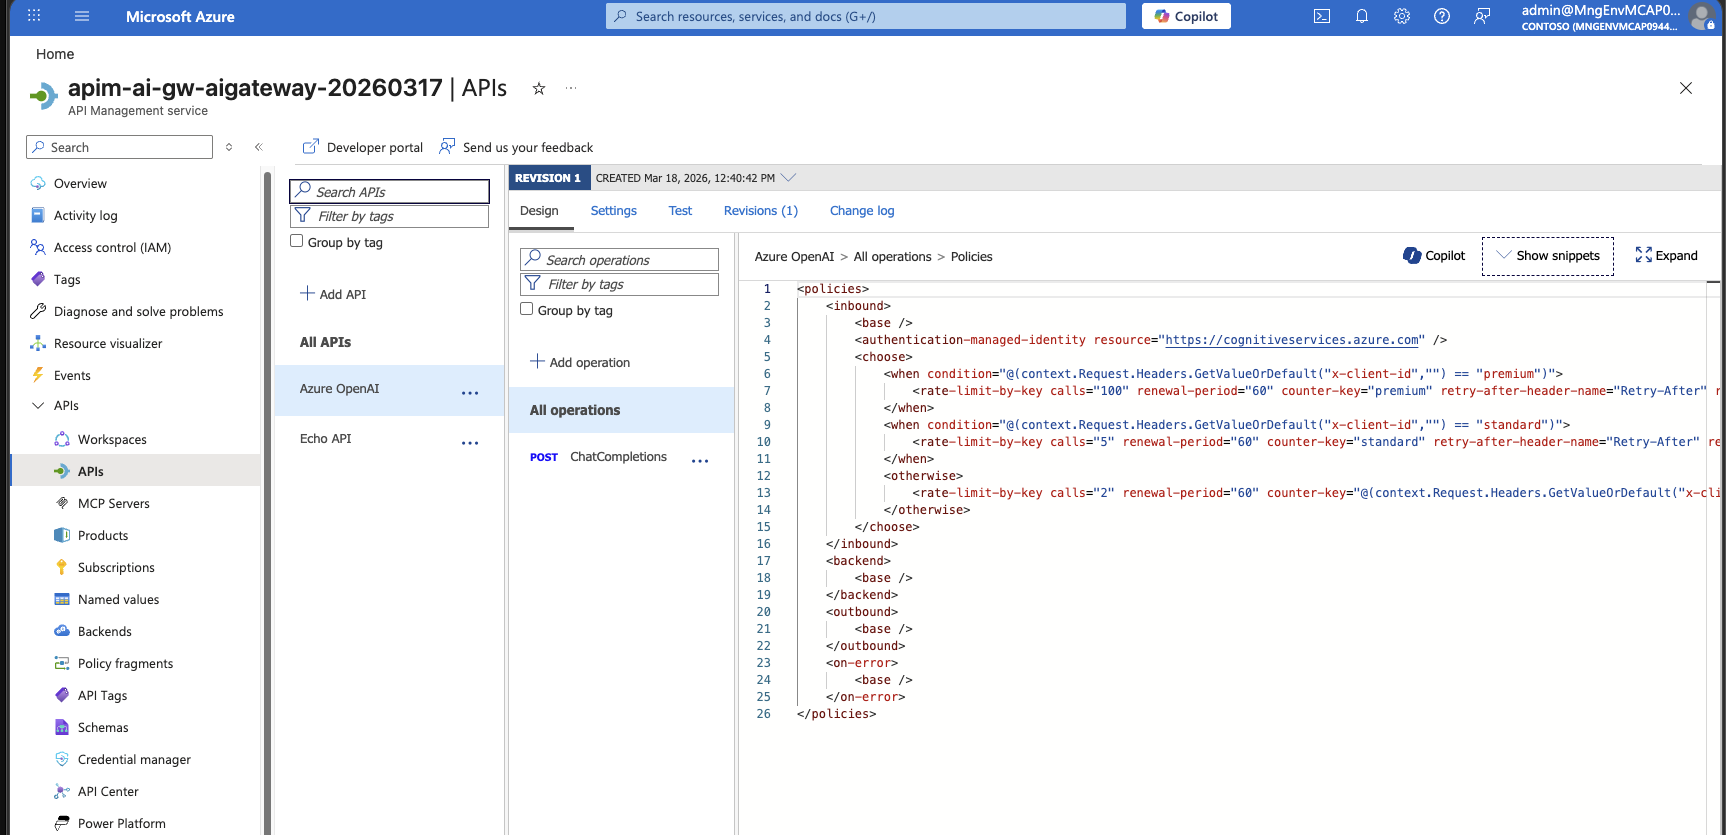

기존 Subscription Key(Built-in all-access)로 테스트합니다.

In [15]:
print("▶ 실습 C 준비: API 레벨에 <choose> 조건부 정책 적용\n")

# 현재 API 정책 조회
current_policy_url = f"https://management.azure.com{APIM_ID}/apis/{API_ID}/policies/policy?api-version=2023-09-01-preview"
result = subprocess.run(
    ["az", "rest", "--method", "GET", "--url", current_policy_url],
    capture_output=True, text=True
)
if result.returncode == 0 and result.stdout.strip():
    try:
        stdout_clean = result.stdout.lstrip('\ufeff')
        current_xml = json.loads(stdout_clean).get("properties", {}).get("value", "")
        print(f"  📋 현재 API 정책:\n{current_xml[:300]}\n")
    except json.JSONDecodeError:
        print("  ℹ️ 현재 API 레벨 정책 없음 (기본 상태)\n")
else:
    print("  ℹ️ 현재 API 레벨 정책 없음 (기본 상태)\n")

# <choose> 조건부 정책: x-client-id에 따라 다른 rate limit 적용
api_policy_xml = """<policies>
    <inbound>
        <base />
        <authentication-managed-identity resource="https://cognitiveservices.azure.com" />
        <choose>
            <when condition="@(context.Request.Headers.GetValueOrDefault(&quot;x-client-id&quot;,&quot;&quot;) == &quot;premium&quot;)">
                <rate-limit-by-key calls="100" renewal-period="60"
                    counter-key="premium"
                    remaining-calls-header-name="x-ratelimit-remaining-calls"
                    retry-after-header-name="Retry-After" />
            </when>
            <when condition="@(context.Request.Headers.GetValueOrDefault(&quot;x-client-id&quot;,&quot;&quot;) == &quot;standard&quot;)">
                <rate-limit-by-key calls="5" renewal-period="60"
                    counter-key="standard"
                    remaining-calls-header-name="x-ratelimit-remaining-calls"
                    retry-after-header-name="Retry-After" />
            </when>
            <otherwise>
                <rate-limit-by-key calls="2" renewal-period="60"
                    counter-key="@(context.Request.Headers.GetValueOrDefault(&quot;x-client-id&quot;,&quot;anonymous&quot;))"
                    remaining-calls-header-name="x-ratelimit-remaining-calls"
                    retry-after-header-name="Retry-After" />
            </otherwise>
        </choose>
    </inbound>
    <backend>
        <base />
    </backend>
    <outbound>
        <base />
    </outbound>
    <on-error>
        <base />
    </on-error>
</policies>"""

print("  📝 적용할 정책:")
print("     premium  → 분당 100회")
print("     standard → 분당 5회")
print("     기타/미지정 → 분당 2회\n")

policy_body = json.dumps({"properties": {"format": "xml", "value": api_policy_xml}})
result = subprocess.run(
    ["az", "rest", "--method", "PUT", "--url", current_policy_url, "--body", policy_body],
    capture_output=True, text=True
)

if result.returncode == 0:
    print("  ✅ API 레벨 조건부 정책 적용 완료!")
else:
    print(f"  ❌ 정책 적용 실패: {result.stderr[:200]}")

▶ 실습 C 준비: API 레벨에 <choose> 조건부 정책 적용

  ℹ️ 현재 API 레벨 정책 없음 (기본 상태)

  📝 적용할 정책:
     premium  → 분당 100회
     standard → 분당 5회
     기타/미지정 → 분당 2회

  ✅ API 레벨 조건부 정책 적용 완료!


---
### 테스트: 티어별 차등 제한 확인

같은 Subscription Key로 호출하되, `x-client-id` 헤더를 바꿔가며 조건 분기를 검증합니다.

- **헤더 없음 (anonymous)** → 2회 제한 → 3번째에 429
- **standard** → 5회 제한 → 6번째에 429
- **premium** → 100회 제한 → 429 없이 통과

In [13]:
print("▶ 실습 C: 조건부 정책 테스트 (<choose> 기반 티어별 rate limit)\n")

SUBSCRIPTION_KEY = os.getenv("APIM_SUBSCRIPTION_KEY")
assert SUBSCRIPTION_KEY, "❌ APIM_SUBSCRIPTION_KEY가 없습니다."

def call_with_tier(client_id=None, prompt="Say OK", max_tokens=10):
    """x-client-id 헤더를 포함(또는 미포함)하여 호출"""
    headers = {
        "Content-Type": "application/json",
        "Ocp-Apim-Subscription-Key": SUBSCRIPTION_KEY,
    }
    if client_id:
        headers["x-client-id"] = client_id
    return requests.post(
        BASE_URL,
        params={"api-version": API_VERSION},
        headers=headers,
        json={"messages": [{"role": "user", "content": prompt}], "max_tokens": max_tokens},
        timeout=30
    )

# ── 테스트 시나리오 ──
scenarios = [
    {"tier": None,        "label": "헤더 없음 (otherwise → 2회/분)", "max_calls": 5},
    {"tier": "standard",  "label": "standard (when → 5회/분)",      "max_calls": 8},
    {"tier": "premium",   "label": "premium  (when → 100회/분)",    "max_calls": 5},
]

for sc in scenarios:
    tier = sc["tier"]
    label = sc["label"]
    print(f"── {label} ──\n")

    results = []
    for i in range(1, sc["max_calls"] + 1):
        resp = call_with_tier(client_id=tier)
        remaining = resp.headers.get("x-ratelimit-remaining-calls", "N/A")

        if resp.status_code == 429:
            retry_after = resp.headers.get("Retry-After", "N/A")
            print(f"  [{i}] 🚫 429 Rate Limit!  Retry-After: {retry_after}s")
            results.append(429)
            break
        elif resp.status_code == 200:
            print(f"  [{i}] ✅ 200  남은 호출: {remaining}")
            results.append(200)
        else:
            print(f"  [{i}] ⚠️ {resp.status_code}: {resp.text[:80]}")
            results.append(resp.status_code)
        time.sleep(0.3)

    ok = results.count(200)
    blocked = results.count(429)
    if blocked > 0:
        print(f"  → {ok}회 성공 후 429 차단 ✅\n")
    else:
        print(f"  → {ok}회 모두 성공 (한도 내) ✅\n")

print("─" * 50)
print("  핵심:")
print("    <choose>로 같은 API에서 티어별 차등 제한 가능")
print("    Product를 나눌 필요 없이 헤더 하나로 분기")
print("─" * 50)

▶ 실습 C: 조건부 정책 테스트 (<choose> 기반 티어별 rate limit)

── 헤더 없음 (otherwise → 2회/분) ──

  [1] ✅ 200  남은 호출: 1
  [2] ✅ 200  남은 호출: 0
  [3] 🚫 429 Rate Limit!  Retry-After: 55s
  → 2회 성공 후 429 차단 ✅

── standard (when → 5회/분) ──

  [1] ✅ 200  남은 호출: 4
  [2] ✅ 200  남은 호출: 3
  [3] ✅ 200  남은 호출: 2
  [4] ✅ 200  남은 호출: 1
  [5] ✅ 200  남은 호출: 0
  [6] 🚫 429 Rate Limit!  Retry-After: 49s
  → 5회 성공 후 429 차단 ✅

── premium  (when → 100회/분) ──

  [1] 🚫 429 Rate Limit!  Retry-After: 30s
  → 0회 성공 후 429 차단 ✅

──────────────────────────────────────────────────
  핵심:
    <choose>로 같은 API에서 티어별 차등 제한 가능
    Product를 나눌 필요 없이 헤더 하나로 분기
──────────────────────────────────────────────────


---
### 정리: API 정책 원복

실습 C에서 추가한 `rate-limit-by-key`를 제거하고 원래 정책(Managed Identity 인증만)으로 복원합니다.

In [ ]:
print("▶ 정리: API 정책 원복\n")

original_policy_xml = """<policies>
    <inbound>
        <base />
        <authentication-managed-identity resource="https://cognitiveservices.azure.com" />
    </inbound>
    <backend>
        <base />
    </backend>
    <outbound>
        <base />
    </outbound>
    <on-error>
        <base />
    </on-error>
</policies>"""

policy_url = f"https://management.azure.com{APIM_ID}/apis/{API_ID}/policies/policy?api-version=2023-09-01-preview"
policy_body = json.dumps({"properties": {"format": "xml", "value": original_policy_xml}})

result = subprocess.run(
    ["az", "rest", "--method", "PUT", "--url", policy_url, "--body", policy_body],
    capture_output=True, text=True
)

if result.returncode == 0:
    print("  ✅ API 정책 원복 완료 (Managed Identity 인증만)")
else:
    print(f"  ❌ 원복 실패: {result.stderr[:150]}")

---
# 실습 D: 조건부 LLM 토큰 제한 (`<choose>` + `llm-token-limit`)

실습 C의 `<choose>` 조건 분기와 `llm-token-limit`(범용 토큰 제한)을 결합합니다.
`x-client-id` 헤더의 티어에 따라 **서로 다른 TPM(분당 토큰)**을 적용합니다.

### 적용할 정책

```
<choose>
├─ x-client-id == "premium"  → llm-token-limit 10,000 TPM
├─ x-client-id == "standard" → llm-token-limit 2,000 TPM
└─ otherwise (미지정/기타)    → llm-token-limit 500 TPM
</choose>
```
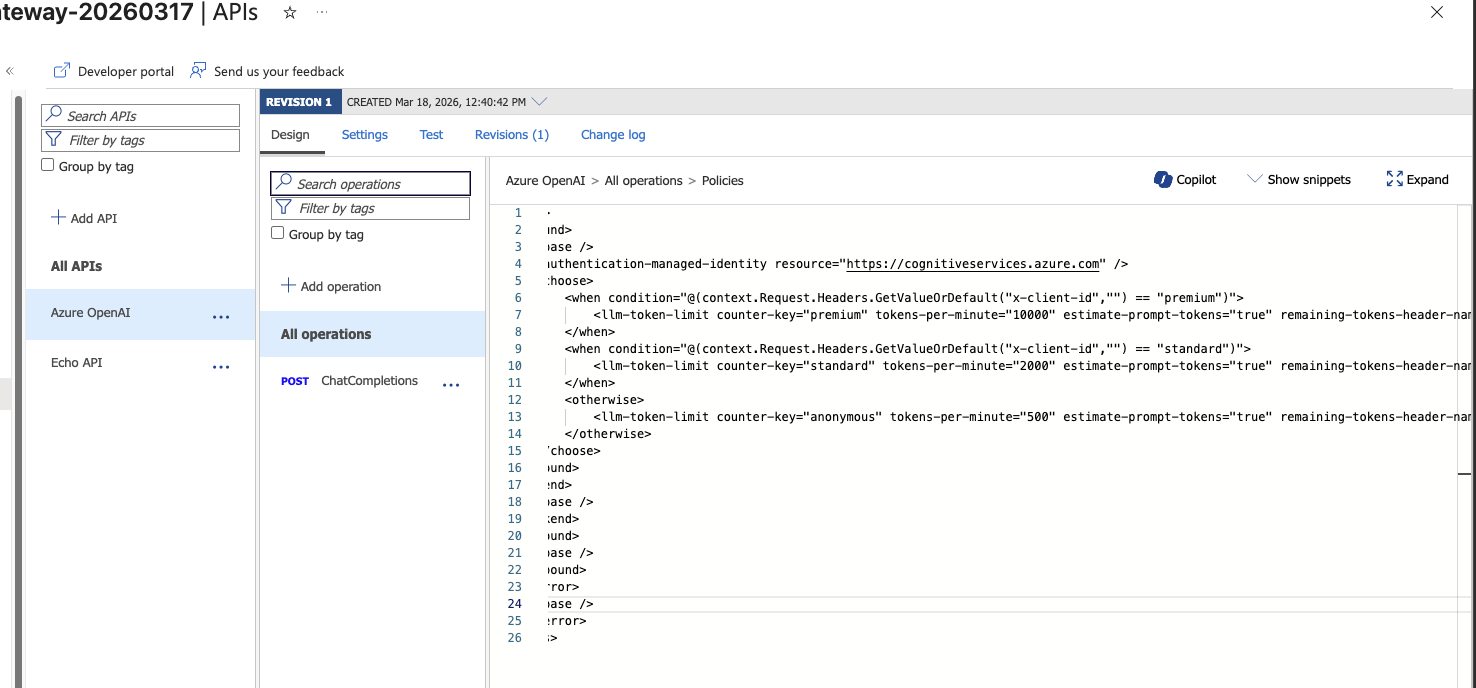

### 왜 `llm-token-limit`인가?

- `azure-openai-token-limit`은 Azure OpenAI 전용
- `llm-token-limit`은 **모든 LLM**(Gemini, Claude 포함)에 동일하게 적용 가능
- 멀티 벤더 AI Gateway에서는 `llm-*` 정책군이 권장됨
- 동작(TPM 제한, 헤더 반환)은 **완전히 동일**

In [16]:
print("▶ 실습 D 준비: API 레벨에 <choose> + llm-token-limit 정책 적용\n")

# <choose> + llm-token-limit: 티어별 TPM 차등 적용
policy_url = f"https://management.azure.com{APIM_ID}/apis/{API_ID}/policies/policy?api-version=2023-09-01-preview"

llm_choose_xml = """<policies>
    <inbound>
        <base />
        <authentication-managed-identity resource="https://cognitiveservices.azure.com" />
        <choose>
            <when condition="@(context.Request.Headers.GetValueOrDefault(&quot;x-client-id&quot;,&quot;&quot;) == &quot;premium&quot;)">
                <llm-token-limit
                    counter-key="premium"
                    tokens-per-minute="10000"
                    estimate-prompt-tokens="true"
                    remaining-tokens-header-name="x-ratelimit-remaining-tokens"
                    tokens-consumed-header-name="x-tokens-consumed" />
            </when>
            <when condition="@(context.Request.Headers.GetValueOrDefault(&quot;x-client-id&quot;,&quot;&quot;) == &quot;standard&quot;)">
                <llm-token-limit
                    counter-key="standard"
                    tokens-per-minute="2000"
                    estimate-prompt-tokens="true"
                    remaining-tokens-header-name="x-ratelimit-remaining-tokens"
                    tokens-consumed-header-name="x-tokens-consumed" />
            </when>
            <otherwise>
                <llm-token-limit
                    counter-key="anonymous"
                    tokens-per-minute="500"
                    estimate-prompt-tokens="true"
                    remaining-tokens-header-name="x-ratelimit-remaining-tokens"
                    tokens-consumed-header-name="x-tokens-consumed" />
            </otherwise>
        </choose>
    </inbound>
    <backend>
        <base />
    </backend>
    <outbound>
        <base />
    </outbound>
    <on-error>
        <base />
    </on-error>
</policies>"""

print("  📝 적용할 정책:")
print("     premium  → llm-token-limit 10,000 TPM")
print("     standard → llm-token-limit 2,000 TPM")
print("     기타/미지정 → llm-token-limit 500 TPM\n")

policy_body = json.dumps({"properties": {"format": "xml", "value": llm_choose_xml}})
result = subprocess.run(
    ["az", "rest", "--method", "PUT", "--url", policy_url, "--body", policy_body],
    capture_output=True, text=True
)

if result.returncode == 0:
    print("  ✅ 조건부 llm-token-limit 정책 적용 완료!")
else:
    print(f"  ❌ 정책 적용 실패: {result.stderr[:200]}")

▶ 실습 D 준비: API 레벨에 <choose> + llm-token-limit 정책 적용

  📝 적용할 정책:
     premium  → llm-token-limit 10,000 TPM
     standard → llm-token-limit 2,000 TPM
     기타/미지정 → llm-token-limit 500 TPM

  ✅ 조건부 llm-token-limit 정책 적용 완료!


---
### 테스트: 티어별 TPM 차등 확인

같은 Subscription Key + 큰 요청(max_tokens=500)으로 호출하되, `x-client-id`를 바꿔가며:

- **헤더 없음** → 500 TPM → 첫 요청에서 바로 429
- **standard** → 2,000 TPM → 몇 회 후 429
- **premium** → 10,000 TPM → 429 없이 통과

In [17]:
print("▶ 실습 D: 조건부 LLM 토큰 제한 (<choose> + llm-token-limit)\n")

SUBSCRIPTION_KEY = os.getenv("APIM_SUBSCRIPTION_KEY")
assert SUBSCRIPTION_KEY, "❌ APIM_SUBSCRIPTION_KEY가 없습니다."

def call_llm_tier(client_id=None, prompt="Write a detailed analysis of AI trends.", max_tokens=500):
    headers = {
        "Content-Type": "application/json",
        "Ocp-Apim-Subscription-Key": SUBSCRIPTION_KEY,
    }
    if client_id:
        headers["x-client-id"] = client_id
    return requests.post(
        BASE_URL,
        params={"api-version": API_VERSION},
        headers=headers,
        json={"messages": [{"role": "user", "content": prompt}], "max_tokens": max_tokens},
        timeout=30
    )

scenarios = [
    {"tier": None,       "label": "헤더 없음 (otherwise → 500 TPM)",  "max_calls": 3},
    {"tier": "standard", "label": "standard (when → 2,000 TPM)",     "max_calls": 8},
    {"tier": "premium",  "label": "premium  (when → 10,000 TPM)",    "max_calls": 5},
]

for sc in scenarios:
    tier = sc["tier"]
    print(f"── {sc['label']} ──\n")

    total_tokens = 0
    results = []

    for i in range(1, sc["max_calls"] + 1):
        resp = call_llm_tier(client_id=tier)
        remaining = resp.headers.get("x-ratelimit-remaining-tokens", "N/A")
        consumed = resp.headers.get("x-tokens-consumed", "N/A")

        if resp.status_code == 429:
            retry_after = resp.headers.get("Retry-After", "N/A")
            print(f"  [{i}] 🚫 429 Token Limit!  Retry-After: {retry_after}s  (누적: {total_tokens})")
            results.append(429)
            break
        elif resp.status_code == 200:
            tokens = resp.json().get("usage", {}).get("total_tokens", 0)
            total_tokens += tokens
            print(f"  [{i}] ✅ 200  사용:{tokens}  남은:{remaining}  (누적: {total_tokens})")
            results.append(200)
        else:
            print(f"  [{i}] ⚠️ {resp.status_code}: {resp.text[:80]}")
            results.append(resp.status_code)
        time.sleep(0.3)

    ok = results.count(200)
    blocked = results.count(429)
    if blocked > 0:
        print(f"  → {ok}회 성공, 누적 {total_tokens} 토큰 후 429 차단 ✅\n")
    else:
        print(f"  → {ok}회 모두 성공, 누적 {total_tokens} 토큰 (한도 내) ✅\n")

print("─" * 60)
print("  핵심:")
print("    <choose> + llm-token-limit 조합으로")
print("    티어별 TPM 차등 제한을 멀티 LLM 호환으로 구현 가능")
print("    → premium은 여유롭게, 무료 티어는 빠르게 차단")
print("─" * 60)

▶ 실습 D: 조건부 LLM 토큰 제한 (<choose> + llm-token-limit)

── 헤더 없음 (otherwise → 500 TPM) ──

  [1] ✅ 200  사용:515  남은:0  (누적: 515)
  [2] 🚫 429 Token Limit!  Retry-After: 59s  (누적: 515)
  → 1회 성공, 누적 515 토큰 후 429 차단 ✅

── standard (when → 2,000 TPM) ──

  [1] ✅ 200  사용:515  남은:1485  (누적: 515)
  [2] ✅ 200  사용:515  남은:970  (누적: 1030)
  [3] ✅ 200  사용:515  남은:455  (누적: 1545)
  [4] ✅ 200  사용:515  남은:0  (누적: 2060)
  [5] 🚫 429 Token Limit!  Retry-After: 48s  (누적: 2060)
  → 4회 성공, 누적 2060 토큰 후 429 차단 ✅

── premium  (when → 10,000 TPM) ──

  [1] ✅ 200  사용:515  남은:9485  (누적: 515)
  [2] ✅ 200  사용:515  남은:8970  (누적: 1030)
  [3] ✅ 200  사용:515  남은:8455  (누적: 1545)
  [4] 🚫 429 Token Limit!  Retry-After: 30s  (누적: 1545)
  → 3회 성공, 누적 1545 토큰 후 429 차단 ✅

────────────────────────────────────────────────────────────
  핵심:
    <choose> + llm-token-limit 조합으로
    티어별 TPM 차등 제한을 멀티 LLM 호환으로 구현 가능
    → premium은 여유롭게, 무료 티어는 빠르게 차단
────────────────────────────────────────────────────────────


In [18]:
print("▶ 정리: API 정책 원복 (실습 D 후)\n")

original_xml = """<policies>
    <inbound>
        <base />
        <authentication-managed-identity resource="https://cognitiveservices.azure.com" />
    </inbound>
    <backend><base /></backend>
    <outbound><base /></outbound>
    <on-error><base /></on-error>
</policies>"""

policy_url = f"https://management.azure.com{APIM_ID}/apis/{API_ID}/policies/policy?api-version=2023-09-01-preview"
policy_body = json.dumps({"properties": {"format": "xml", "value": original_xml}})

result = subprocess.run(
    ["az", "rest", "--method", "PUT", "--url", policy_url, "--body", policy_body],
    capture_output=True, text=True
)
print(f"  {'✅' if result.returncode == 0 else '❌'} API 정책 원복 {'완료' if result.returncode == 0 else '실패'}")

▶ 정리: API 정책 원복 (실습 D 후)

  ✅ API 정책 원복 완료


---
# 참고: LLM 범용 토큰 제어 (`llm-token-limit`)

## Azure OpenAI 전용 vs 범용 LLM 정책

APIM은 **같은 기능**에 대해 두 벌의 정책을 제공합니다.

| Azure OpenAI 전용 | 범용 LLM | 차이 |
|---|---|---|
| `azure-openai-token-limit` | `llm-token-limit` | 대상 백엔드가 다름 |
| `azure-openai-emit-token-metric` | `llm-emit-token-metric` | 메트릭 전송 대상 |
| `azure-openai-semantic-cache-lookup` | `llm-semantic-cache-lookup` | 캐시 대상 |
| `azure-openai-semantic-cache-store` | `llm-semantic-cache-store` | 캐시 저장 대상 |

## 언제 어떤 것을 쓰나?

### `azure-openai-token-limit` 을 쓰는 경우

- 백엔드가 **Azure OpenAI만** 있을 때
- Azure OpenAI 전용 정책군(`azure-openai-emit-token-metric`, `azure-openai-semantic-cache-*`)과 함께 **통일된 운영**

```xml
<azure-openai-token-limit
    counter-key="@(context.Subscription.Id)"
    tokens-per-minute="5000"
    estimate-prompt-tokens="true"
    remaining-tokens-header-name="x-ratelimit-remaining-tokens" />
```

### `llm-token-limit` 을 쓰는 경우

- 백엔드에 **Azure OpenAI 외 다른 LLM**(Google Gemini, Anthropic Claude, 자체 호스팅 모델 등)이 포함될 때
- **멀티 벤더 AI Gateway**를 운영할 때
- Azure AI Model Inference API 또는 OpenAI-compatible 엔드포인트를 사용할 때

```xml
<llm-token-limit
    counter-key="@(context.Subscription.Id)"
    tokens-per-minute="5000"
    estimate-prompt-tokens="true"
    remaining-tokens-header-name="x-ratelimit-remaining-tokens" />
```

### 정책 선택 가이드

```
백엔드가 Azure OpenAI만 있는가?
├─ Yes → azure-openai-token-limit
│        (Azure OpenAI 전용 정책군과 통일)
└─ No  → llm-token-limit
         (멀티 벤더 호환, Azure OpenAI 포함 가능)
```

## SKU 제약 (공통)

두 정책 모두 **Consumption SKU에서는 사용할 수 없습니다.**

| SKU | `azure-openai-token-limit` | `llm-token-limit` |
|---|---|---|
| Developer | ✅ | ✅ |
| Basic / Basic v2 | ✅ | ✅ |
| Standard / Standard v2 | ✅ | ✅ |
| Premium / Premium v2 | ✅ | ✅ |
| **Consumption** | ❌ | ❌ |

Consumption에서 제한이 필요하면 `rate-limit`(요청 수 기반)으로 대체해야 합니다.

## 전체 제한 정책 비교

| 정책 | 제한 단위 | Consumption | 용도 |
|---|---|---|---|
| `rate-limit` | 요청 횟수/분 (구독 기준) | ✅ | 가장 단순한 호출 제한 |
| `rate-limit-by-key` | 요청 횟수/분 (key 기준) | ❌ | 팀별/IP별 요청 제한 |
| `quota` | 요청 총량 (일/월 단위, 구독 기준) | ✅ | 장기 사용량 관리 |
| `quota-by-key` | 요청 총량 (key 기준) | ❌ | 팀별 월간 예산 |
| `azure-openai-token-limit` | 토큰/분 (TPM) | ❌ | Azure OpenAI 토큰 비용 제어 |
| `llm-token-limit` | 토큰/분 (TPM) | ❌ | 멀티 LLM 토큰 비용 제어 |